# Credit Risk Classification System

### Students:
- Razak Nadaf (2302182)
- Retuja Havle (2302177)
- Saurabh Havle (2302176)

### Subject:
Data Science – CA2 (Mini Project)

## Problem Statement

The objective of this project is to build a machine learning model that classifies customers as high risk or low risk based on their financial and personal details.

This helps financial institutions reduce risk while approving loans.

## Dataset Description

We used the German Credit Dataset.

- Total Records: 1000
- Features: 20+
- Target Variable: credit_risk

The dataset contains information such as age, loan amount, employment status, and credit history.

Dataset Source:
https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans


In [2]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv'
df = pd.read_csv(url)
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

## EDA

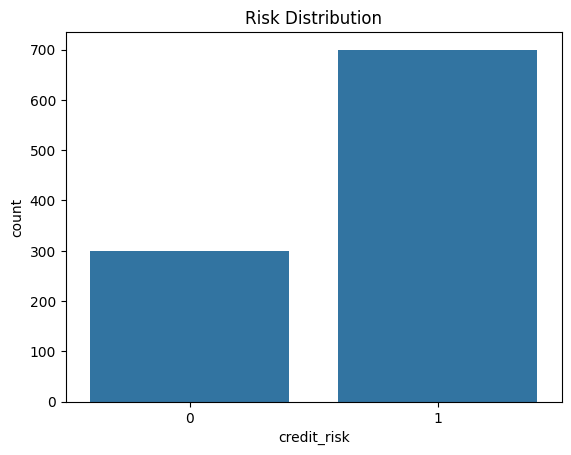

In [6]:
sns.countplot(x='credit_risk', data=df)
plt.title('Risk Distribution')
plt.show()

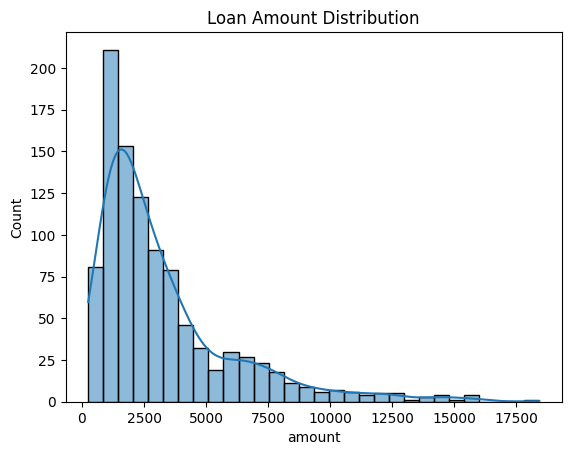

In [7]:
sns.histplot(df['amount'], bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

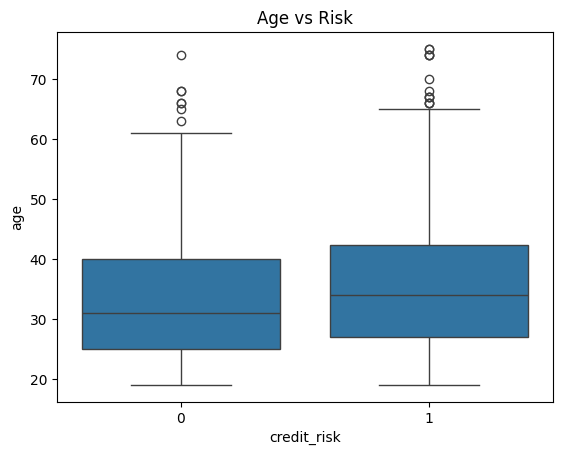

In [9]:
sns.boxplot(x='credit_risk', y='age', data=df)
plt.title('Age vs Risk')
plt.show()

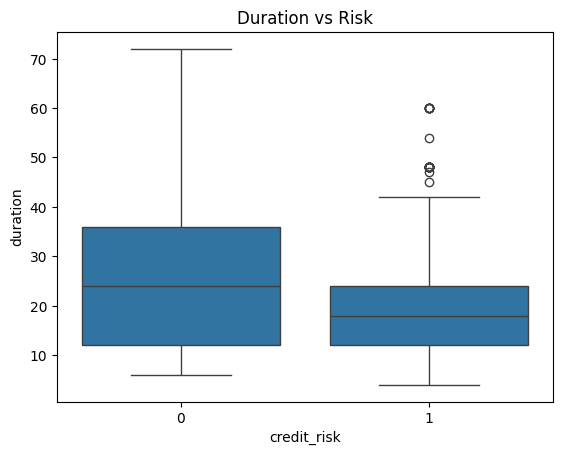

In [10]:
sns.boxplot(x='credit_risk', y='duration', data=df)
plt.title('Duration vs Risk')
plt.show()

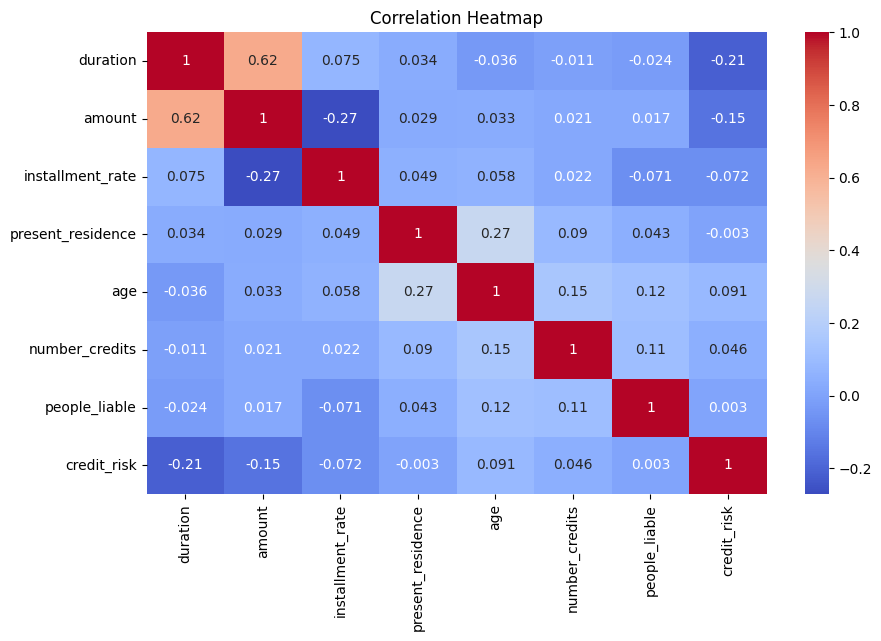

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Preprocessing

In [12]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Models

In [15]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print('Logistic Accuracy:', lr_acc)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print('KNN Accuracy:', knn_acc)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print('Decision Tree Accuracy:', dt_acc)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print('Random Forest Accuracy:', rf_acc)

Logistic Accuracy: 0.745
KNN Accuracy: 0.735
Decision Tree Accuracy: 0.72
Random Forest Accuracy: 0.795


## GridSearch (Improvement)

In [16]:
params = {'n_neighbors': [3,5,7,9]}
grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
best_pred = best_knn.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)

print('Best Params:', grid.best_params_)
print('Improved KNN Accuracy:', best_acc)

Best Params: {'n_neighbors': 9}
Improved KNN Accuracy: 0.74


## Confusion Matrices

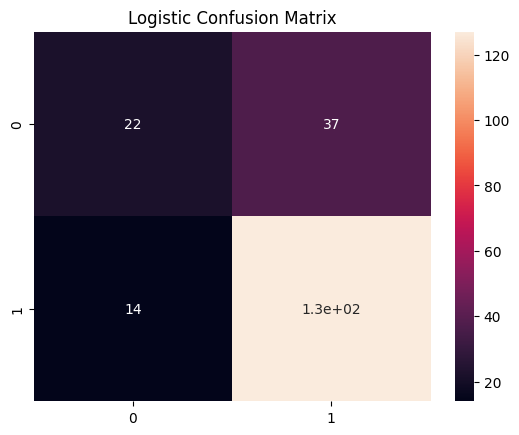

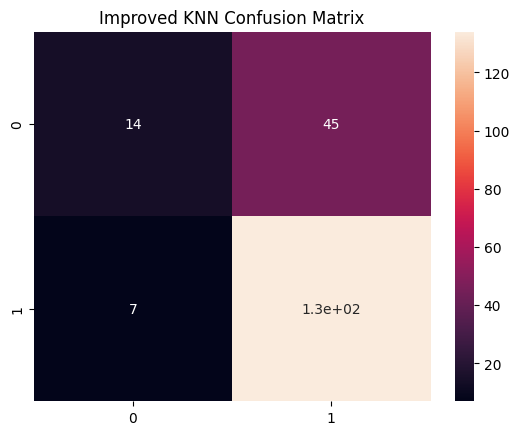

In [17]:
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True)
plt.title('Logistic Confusion Matrix')
plt.show()

sns.heatmap(confusion_matrix(y_test, best_pred), annot=True)
plt.title('Improved KNN Confusion Matrix')
plt.show()

## Model Comparison

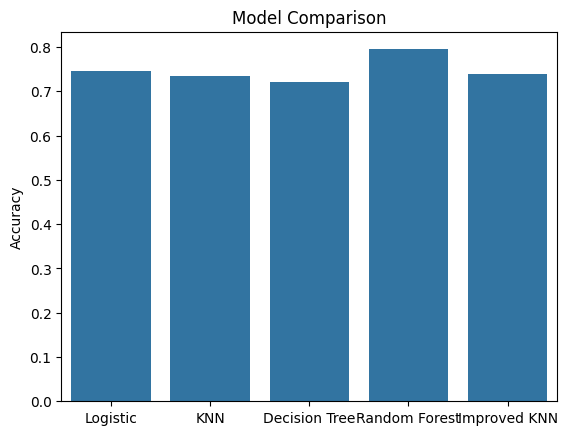

In [18]:
models = ['Logistic', 'KNN', 'Decision Tree', 'Random Forest', 'Improved KNN']
scores = [lr_acc, knn_acc, dt_acc, rf_acc, best_acc]

sns.barplot(x=models, y=scores)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

## Clustering

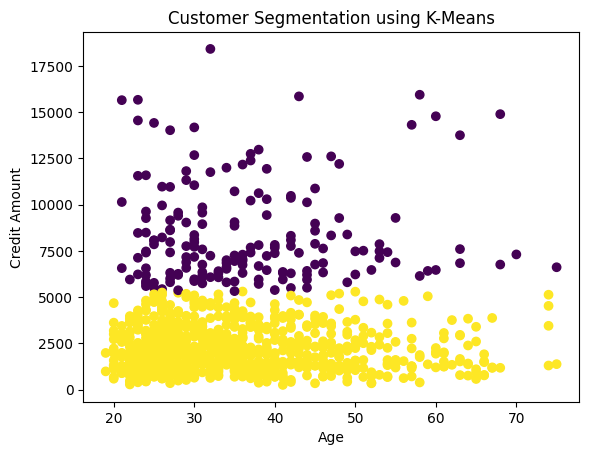

In [20]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(X['age'], X['amount'], c=clusters)
plt.xlabel('Age')
plt.ylabel('Credit Amount')
plt.title('Customer Segmentation using K-Means')
plt.show()

## Save Model

In [21]:
import pickle
pickle.dump(rf, open('model.pkl','wb'))
print('Model saved successfully')

Model saved successfully
